In [1]:
import sys
sys.path.append('/Users/mariana/Documents/col/lts4/survan')
sys.path.append('/Users/mariana/Documents/col/lts4/tdsurv/lib')


from tdsurv import CoxPH
from tdsurv import concordance_index as tdsurv_ci
from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

# Random Walk 

In [2]:
from scipy.special import expit as sigmoid
from utils import get_targets_and_masks

In [3]:
# Borrowed from tdsurv (https://github.com/spotify-research/tdsurv/blob/main/notebooks/random-walk-final.ipynb)
def make_generator(mat, sigma, sigma0, thetas, bias, rng):
    """Sample from a Gauss-Markov process.
    
    Initial state:
    
        x_0 = noise(sigma0)
    
    Transition dynamics:
    
        x_nxt = np.dot(mat, x) + noise(sigma)
        
    Churn probability:
    
        p = sigmoid(np.dot(x, thetas) + bias)
    """
    n_dims = mat.shape[0]
    def gen(n_samples, horizon):
        seqs = np.zeros((n_samples, horizon + 1, n_dims + 1))
        ts = np.zeros(n_samples, dtype=int)
        cs = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            seqs[i, 0] = np.append(sigma0 * rng.normal(size=n_dims), 1)
            ts[i] = 1
            for j in range(0, horizon):
                p = sigmoid(np.dot(seqs[i, j, :-1], thetas) + bias)
                if rng.uniform() < p:
                    break
                ts[i] += 1
                seqs[i, j + 1] = np.append(
                    np.dot(mat, seqs[i, j, :-1]) + sigma * rng.normal(size=n_dims),
                    1,
                )
            if ts[i] > horizon:
                ts[i] = horizon
                cs[i] = True
        tgt_lm, hws_lm, mask_lm = get_targets_and_masks(seqs, ts, cs, landmark=True)
        return (seqs.astype(np.float32), ts, cs, tgt_lm, hws_lm, mask_lm)
    return gen

In [4]:
rng = np.random.default_rng(seed=0)
n_dims = 20
horizon = 10
d = n_dims + 1

# Churn parameters.
thetas = rng.normal(size=n_dims)
bias = -.5

# Transition dynamics.
mat = 1.0 * np.eye(n_dims)
sigma = 0.5
sigma0 = 1.0 # Affect results quite a lot

gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
seqs_v, ts_v, cs_v, y_v, hws_v, m_v = gen(n_samples=10000, horizon=horizon)

In [5]:
H = horizon + 1

In [6]:
cs_v.sum()/len(cs_v)

0.2186

In [7]:
# N-fold cross-validation
n_folds = 5
data = list()
for i in range(n_folds):
    data.append(gen(n_samples=300, horizon=horizon))

In [8]:
# "dummy" config file
config_path = '../configs/config_rw.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [ ]:
%%time

# sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 
taus = [0.01, 0.1, 0.25, 0.5, 0.75, 1.0]
size = 100

rw_ci_dtd = np.zeros((n_folds, len(taus)))
rw_ibs_dtd = np.zeros((n_folds, len(taus)))

l2 = 1e-4
lambda_ = 1.0
avg_h = jnp.zeros((10000, H, H))


for fold in range(n_folds):
    seqs_t, ts_t, cs_t, y_t, hws_t, m_t = data[fold]
    
    print(".", end="")
    # seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

    # Deep TD
    config['axis'] = 2
    config['weight_decay'] = 1e-4
    config['dataset_kwargs']['horizon'] = H
    model = DeepLambdaSA(config, seed=42)
    model.lambda_ = lambda_

    train_gen, test_gen = model.get_train_test(test_size=size)
    train_gen.X = seqs_t[:size]
    train_gen.ts = ts_t[:size]
    train_gen.cs = cs_t[:size]
    train_gen.y = y_t[:size]
    train_gen.mask = m_t[:size]
    train_gen.h_ws = hws_t[:size]

    _ = model.train(train_gen)
    surv = model.survival_curve(seqs_v)
    scores = model.scores(seqs_v, q=0.5)
    rw_ci_dtd[fold, i] = concordance_index(scores, ts_v, cs_v)
    rw_ibs_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_v, cs_v)

    logits = model.forward(model.state.params, seqs_v)
    hs = jax.nn.sigmoid(logits)
    avg_h += hs

print()

.....
CPU times: user 13.7 s, sys: 555 ms, total: 14.2 s
Wall time: 14.6 s


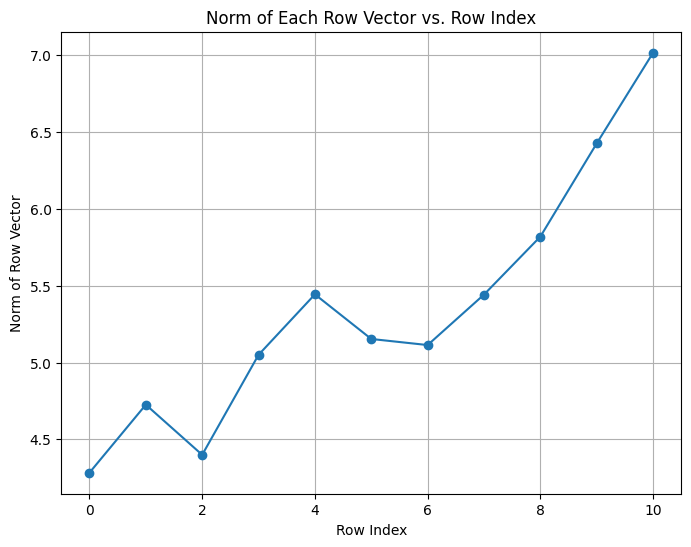

In [10]:
norms = jnp.linalg.norm(seqs_t[50], axis=1)

# Create a plot of the norm values vs. the row indices
plt.figure(figsize=(8, 6))
plt.plot(norms, marker='o', linestyle='-')
plt.xlabel('Row Index')
plt.ylabel('Norm of Row Vector')
plt.title('Norm of Each Row Vector vs. Row Index')
plt.grid(True)
plt.show()

In [140]:
avg_h /= n_folds

In [141]:
fold = 0
size = 100

# Ground truth model:
config['axis'] = 2
config['weight_decay'] = 1e-4
config['dataset_kwargs']['horizon'] = H
model = DeepLambdaSA(config, seed=42)
model.lambda_ = lambda_

train_gen, test_gen = model.get_train_test(test_size=size)
train_gen.X = seqs_v
train_gen.ts = ts_v
train_gen.cs = cs_v
train_gen.y = y_v
train_gen.mask = m_v
train_gen.h_ws = hws_v


In [142]:
_ = model.train(train_gen)

In [143]:
scores = model.scores(seqs_v, q=0.0)
surv = model.survival_curve(seqs_v)
concordance_index(scores, ts_v, cs_v), model.integrated_brier_score(surv[:,0], ts_v, cs_v)

(0.8799372769000856, Array(0.14727417, dtype=float64))

In [144]:
logits = model.forward(model.state.params, seqs_v)
gold_hs = jax.nn.sigmoid(logits)

In [145]:
gold_hs.shape, avg_h.shape

((10000, 11, 11), (10000, 11, 11))

In [146]:
aux = gold_hs[:, :, 0]
aux.shape

(10000, 11)

In [147]:
aux[0][hws_v[0][:, 0]]

Array([0.32273155, 0.5056119 ], dtype=float32)

In [148]:
aux[0]

Array([0.32273155, 0.5056119 , 0.5408475 , 0.5408475 , 0.5408475 ,
       0.5408475 , 0.5408475 , 0.5408475 , 0.5408475 , 0.5408475 ,
       0.5408475 ], dtype=float32)

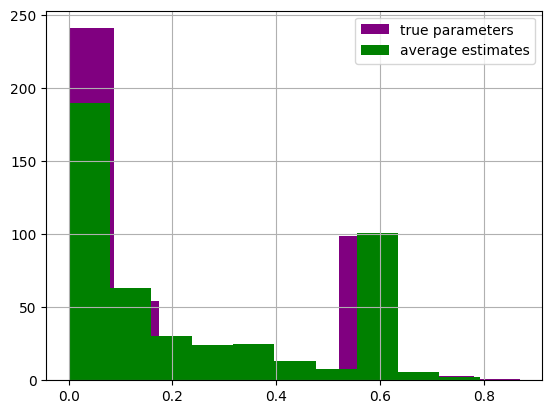

In [149]:
# Given some time t, say, t=3, we take all the columns t from gold_hs and avg_h, and
# collect those values where the column t from hws_v is 1. We then plot histograms of these values
# with orange as the color for gold_hs and blue for avg_h.

t = 3
gold = gold_hs[:100, :, t][hws_v[:100, t, 0] == 1].flatten()
avg = avg_h[:100, :, t][hws_v[:100, t, 0] == 1].flatten()

plt.hist(gold, bins=10, color='purple', label='true parameters')
plt.hist(avg, bins=10, color='green', label='average estimates')
plt.legend()
plt.grid()
plt.show()

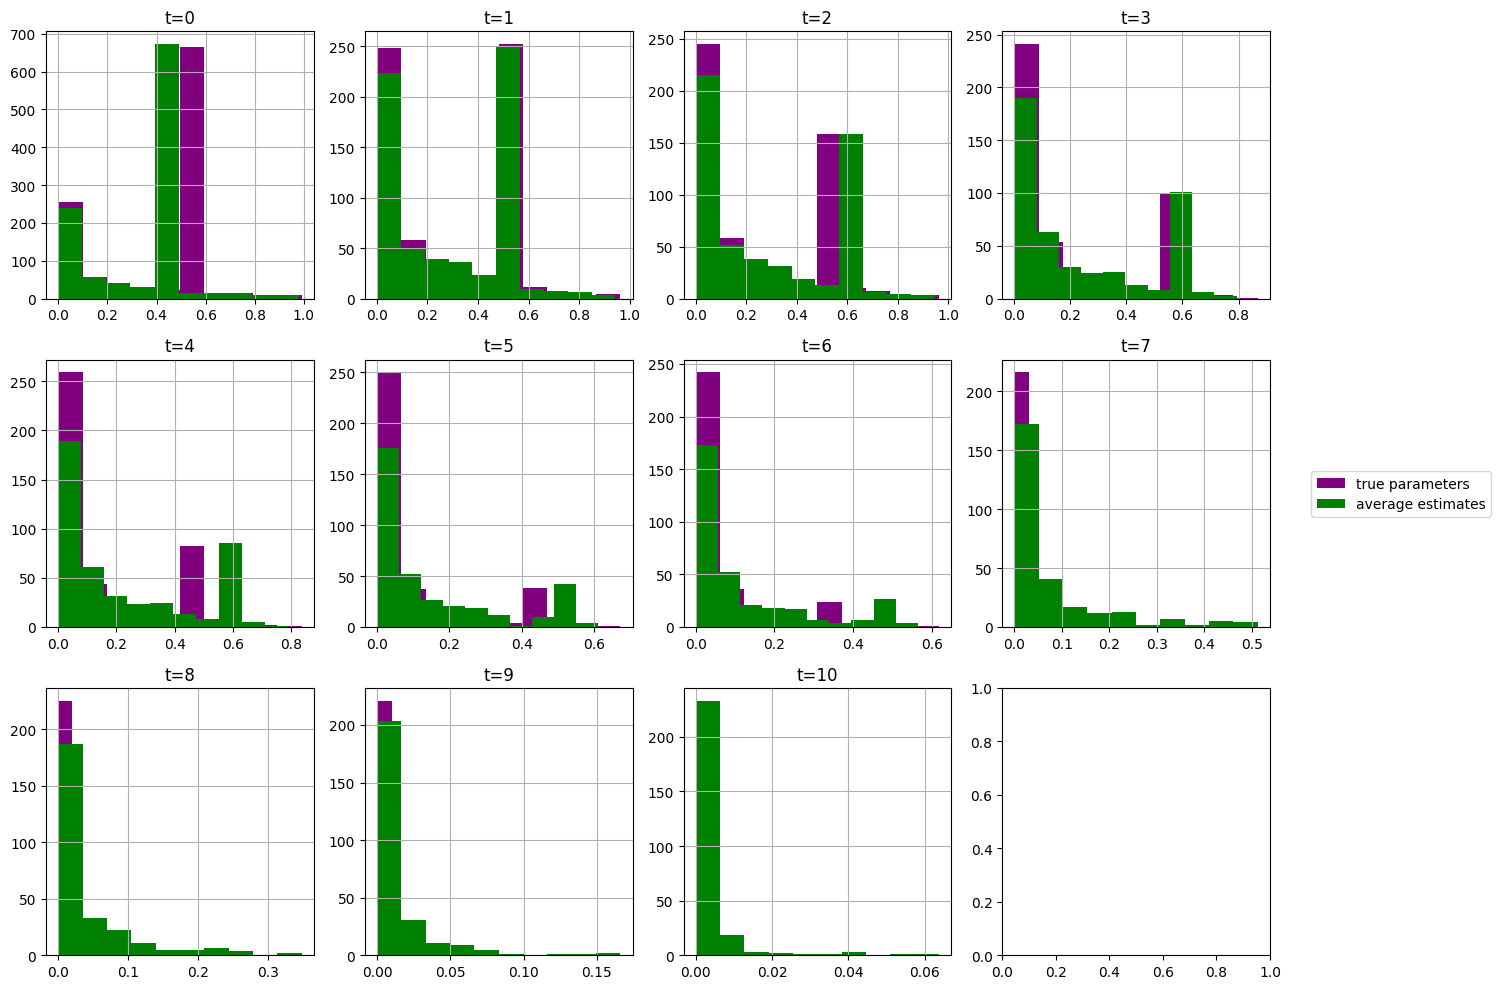

In [150]:
# Make a grid of histograms for all times t using subfigures
fig, axs = plt.subplots(3, 4, figsize=(15, 10))

for i in range(3):
    for j in range(4):
        t = i*4 + j
        if t <= horizon:
            gold = gold_hs[:100, :, t][hws_v[:100, t, 0] == 1].flatten()
            avg = avg_h[:100, :, t][hws_v[:100, t, 0] == 1].flatten()
            axs[i, j].hist(gold, bins=10, color='purple', label='true parameters')
            axs[i, j].hist(avg, bins=10, color='green', label='average estimates')
            axs[i, j].set_title(f't={t}')
            axs[i, j].grid()

# Add a legend at the right of the last subplot
fig.tight_layout()
fig.subplots_adjust(right=0.85)
fig.legend(['true parameters', 'average estimates'], loc='center right')

plt.show()

In [138]:
model_0 = model

In [151]:
model.state.params 

{'cox_linear_model': {'alpha': Array([  0.16375479,   0.18638824,   0.20105462,   0.11025856,
          -0.14755154,  -0.38033304,  -0.61253387,  -1.0200061 ,
          -1.6240008 ,  -2.4123044 , -17.973635  ], dtype=float32),
  'beta': Array([ 0.09645362, -0.06383231,  0.18587671,  0.02742342, -0.41515225,
          0.29440084,  0.76735747,  0.59331125, -0.4776175 , -0.90912974,
         -0.44558427, -0.01480852, -1.2240926 , -0.05823794, -0.6882217 ,
         -0.4421682 , -0.1797623 , -0.24647781,  0.15198329,  0.6392293 ,
         -0.7797918 ], dtype=float32)}}